In [302]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [303]:
df = pd.read_csv("/content/Train.csv")

In [304]:
df

,Id,Sex,Sex Code,State,State Code,Year,Year Code,Ten-Year Age Groups,Ten-Year Age Groups Code,% of Total Deaths,...,temp_sensor_readout,qc_flag_batch_3,legacy_index_offset,adjusted_pop_trend,confidence_spread_metric,Underlying_Cause,Contributing_Cause,Manner_of_Death,temporal_alignment_proxy,Target
0,0,F,F,Alabama,1.000000,2006.000000,NaN,< 1 year,1,0.000000,...,0.798753,0.514077,26,2.993754e+04,1.292495,1482,0.119917,3,async,NaN
1,1,F,F,Alabama,1.000000,2006.000000,2006.000000,1-4 years,1-4,0.000000,...,0.522892,-0.018962,19,NaN,NaN,6257,-0.047118,1,sync,NaN
2,2,F,F,Alabama,1.000000,2006.000000,NaN,5-14 years,5-14,0.000000,...,-0.131577,-1.147265,-44,3.066000e+05,1.728413,1171,0.051464,4,sync,55.000000
3,3,NaN,NaN,Alabama,-91.432811,1980.124326,1980.124326,NaN,15-24,-0.079738,...,0.931934,0.214202,-24,2.849991e+06,NaN,6902,-0.073988,4,sync,NaN
4,4,F,F,Alabama,1.000000,2006.000000,2006.000000,25-34 years,25-34,0.000000,...,1.150727,-0.235712,22,3.013313e+05,1.243071,5361,0.190123,2,sync,327.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11874,2270,F,F,Indiana,110.432811,NaN,2044.875674,85+ years,85+,0.109738,...,1.047053,-0.725908,-45,NaN,-0.310852,5987,0.095320,4,async,42606.990927
11875,9956,M,NaN,Indiana,110.432811,2033.875674,1982.124326,75-84 years,75-84,-0.059738,...,1.676185,0.840593,-14,-2.480187e+06,-0.609987,3590,0.006963,2,pending,NaN
11876,1149,F,NaN,Delaware,-82.432811,2037.875674,1986.124326,< 1 year,1,-0.079738,...,-1.598063,0.162914,-37,NaN,NaN,7179,0.002680,1,async,30873.990927
11877,9791,M,M,Illinois,-75.432811,NaN,1982.124326,75-84 years,75-84,-0.049738,...,2.355477,0.180483,16,NaN,1.072109,5266,0.021382,2,async,-17744.990927


##### Initial Data Analysis

In [305]:
df.shape

(11879, 27)

In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11879 entries, 0 to 11878
Data columns (total 27 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Id                                        11879 non-null  int64  
 1   Sex                                       10449 non-null  object 
 2   Sex Code                                  10426 non-null  object 
 3   State                                     10482 non-null  object 
 4   State Code                                11879 non-null  float64
 5   Year                                      7407 non-null   float64
 6   Year Code                                 7352 non-null   float64
 7   Ten-Year Age Groups                       10379 non-null  object 
 8   Ten-Year Age Groups Code                  10423 non-null  object 
 9   % of Total Deaths                         11879 non-null  float64
 10  Population                        

In [307]:
df.describe()

,Id,State Code,Year,Year Code,% of Total Deaths,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,Crude Rate Standard Error,temp_sensor_readout,qc_flag_batch_3,legacy_index_offset,adjusted_pop_trend,confidence_spread_metric,Underlying_Cause,Contributing_Cause,Manner_of_Death,Target
count,11879.000000,11879.000000,7407.000000,7352.000000,11879.000000,7373.000000,11879.000000,7286.000000,11879.000000,11879.000000,11879.000000,11879.000000,5.521000e+03,7286.000000,11879.000000,11879.000000,11879.000000,7459.000000
mean,5501.505514,24.287310,2013.020893,2012.681305,0.005335,2239.662124,2062.463086,2123.165120,47.287300,0.001603,0.000630,-0.456941,2.995413e+05,1.051487,5514.596767,0.001426,2.511154,2345.643033
std,3179.566483,42.846270,12.088312,11.854554,0.036834,11419.929431,11137.394489,11832.831609,224.838399,1.015420,0.499660,29.000461,1.197231e+06,0.802323,2613.248515,0.100357,1.119342,14234.033002
min,0.000000,-91.432811,1980.124326,1980.124326,-0.079738,-24733.324181,-23989.750021,-25491.464395,-486.653198,-3.634669,-1.890751,-50.000000,-2.601965e+06,-4.989797,1000.000000,-0.445656,1.000000,-30820.990927
25%,2751.500000,9.000000,2008.000000,2008.000000,0.000000,53.210000,43.815000,63.992500,4.420000,-0.693968,-0.338444,-26.000000,4.500241e+04,1.060640,3235.000000,-0.066381,2.000000,83.000000
50%,5500.000000,21.000000,2013.000000,2013.000000,0.000000,471.930000,393.170000,502.420000,15.360000,0.007040,0.001539,-1.000000,1.734064e+05,1.122168,5510.000000,0.001307,3.000000,547.000000
75%,8261.500000,40.000000,2018.000000,2017.000000,0.010000,3628.920000,3287.165000,2957.165000,65.520000,0.676934,0.340850,24.000000,4.313546e+05,1.330336,7797.000000,0.069647,4.000000,3814.000000
max,10998.000000,148.432811,2045.875674,2045.875674,0.159738,43664.854181,41597.570021,43983.284395,1254.713198,3.963162,2.149139,49.000000,5.458888e+06,2.529326,9998.000000,0.480151,4.000000,66004.990927


In [308]:
df.describe(include = "object")

,Sex,Sex Code,State,Ten-Year Age Groups,Ten-Year Age Groups Code,Population,State_Age_Combo,Year_dt,temporal_alignment_proxy
count,10449,10426,10482,10379,10423,10493,11879,7942,11879
unique,2,2,51,11,11,8938,536,46,3
top,F,F,Arkansas,35-44 years,45-54,err_260,Hawaii_65-74 years,NULL_TIMESTAMP,pending
freq,7372,7397,330,1034,1038,7,37,1409,3991


In [309]:
df.isna().sum().sort_values(ascending = False)

,0
adjusted_pop_trend,6358
Crude Rate Upper 95% Confidence Interval,4593
confidence_spread_metric,4593
Year Code,4527
Crude Rate,4506
Year,4472
Target,4420
Year_dt,3937
Ten-Year Age Groups,1500
Ten-Year Age Groups Code,1456


In [310]:
(df.isna().mean() *100)

,0
Id,0.000000
Sex,12.038050
Sex Code,12.231669
State,11.760249
State Code,0.000000
Year,37.646267
Year Code,38.109268
Ten-Year Age Groups,12.627326
Ten-Year Age Groups Code,12.256924
% of Total Deaths,0.000000


THey represent same information

In [311]:
df[["Sex","Sex Code"]].drop_duplicates()

,Sex,Sex Code
0,F,F
3,NaN,NaN
5,F,NaN
8,NaN,F
7766,M,M
7772,M,NaN
7796,NaN,M


In [312]:
df[["Ten-Year Age Groups","Ten-Year Age Groups Code"]].drop_duplicates()


,Ten-Year Age Groups,Ten-Year Age Groups Code
0,< 1 year,1
1,1-4 years,1-4
2,5-14 years,5-14
3,NaN,15-24
4,25-34 years,25-34
5,35-44 years,35-44
6,45-54 years,45-54
7,55-64 years,55-64
8,65-74 years,65-74
9,75-84 years,NaN


In [313]:
df.duplicated().sum()

np.int64(0)

In [314]:
df[df["Id"] == 3].T

,3,11694
Id,3,3
Sex,NaN,NaN
Sex Code,NaN,NaN
State,Alabama,Alabama
State Code,-91.432811,-91.432811
Year,1980.124326,1980.124326
Year Code,1980.124326,1980.124326
Ten-Year Age Groups,NaN,NaN
Ten-Year Age Groups Code,15-24,15-24
% of Total Deaths,-0.079738,-0.079738


In [315]:
df.nunique().sort_values()

,0
Sex,2
Sex Code,2
temporal_alignment_proxy,3
Manner_of_Death,4
Ten-Year Age Groups,11
Ten-Year Age Groups Code,11
% of Total Deaths,35
Year,45
Year Code,45
Year_dt,46


In [316]:
df[["State","State Code"]].drop_duplicates().sort_values("State Code").head(10)


,State,State Code
3,Alabama,-91.432811
70,NaN,-91.432811
173,Alaska,-90.432811
8055,NaN,-90.432811
398,NaN,-88.432811
303,Arizona,-88.432811
590,NaN,-87.432811
465,Arkansas,-87.432811
673,NaN,-86.432811
668,California,-86.432811


In [317]:
df["Target"].describe()

,Target
count,7459.000000
mean,2345.643033
std,14234.033002
min,-30820.990927
25%,83.000000
50%,547.000000
75%,3814.000000
max,66004.990927


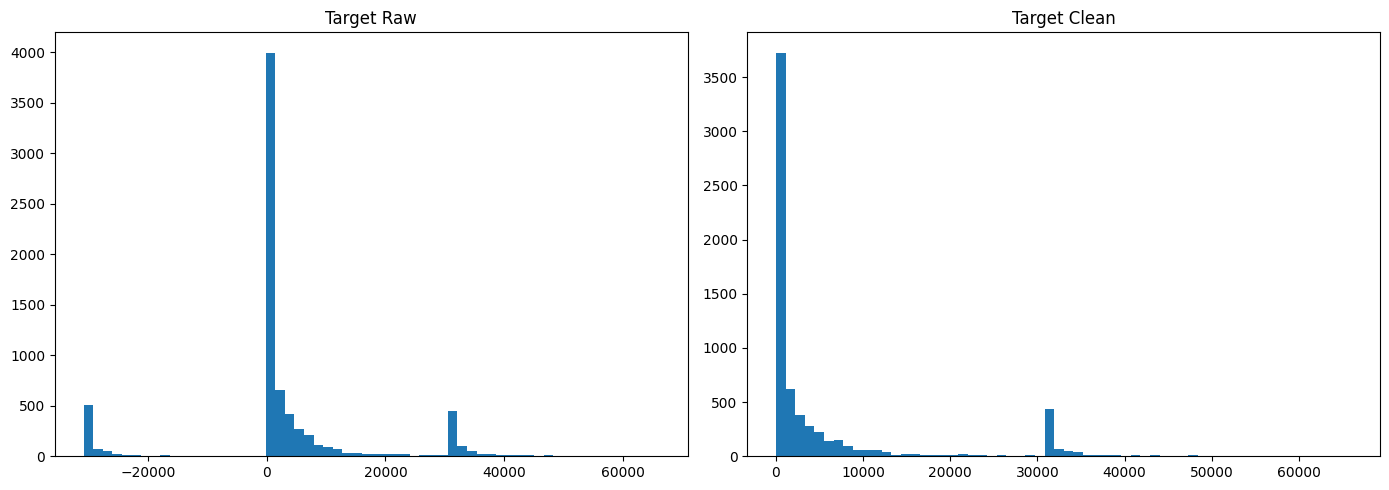

In [318]:
fig, axes = plt.subplots(1, 2, figsize =(14,5))


axes[0].hist(df["Target"].dropna(), bins =60)
axes[0].set_title("Target Raw")


axes[1].hist(df.loc[df["Target"] >=0, "Target"].dropna(), bins=60)
axes[1].set_title("Target Clean")

plt.tight_layout()
plt.show()

In [319]:
import seaborn as sns

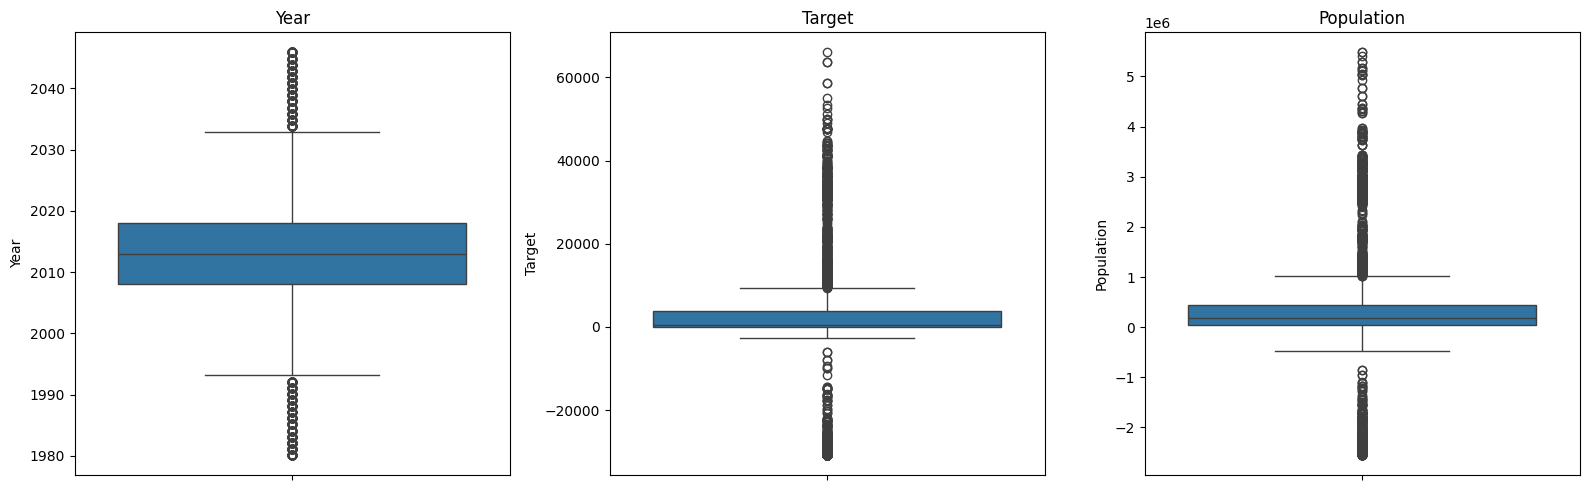

In [320]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df["Year"], ax=axs[0])
axs[0].set_title("Year")

sns.boxplot(y=df["Target"], ax=axs[1])
axs[1].set_title("Target")

sns.boxplot(
    y=pd.to_numeric(df["Population"], errors="coerce"),
    ax=axs[2]
)
axs[2].set_title("Population")

plt.tight_layout()
plt.show()

In [321]:
(df["Target"] < 0).sum()

np.int64(716)

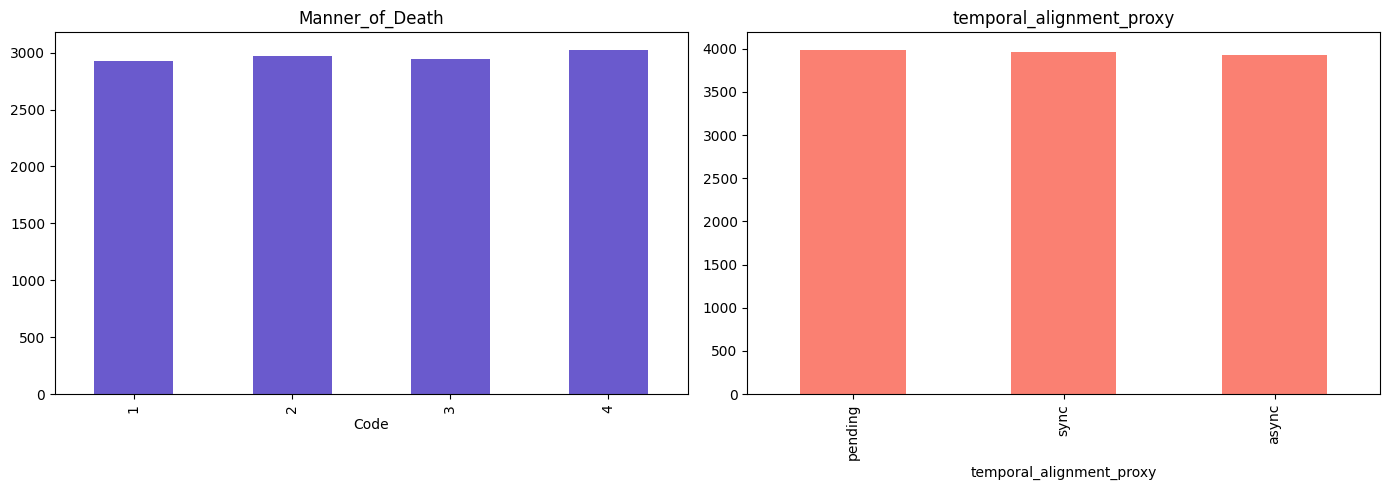

In [322]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Manner_of_Death"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="slateblue")
axes[0].set_title("Manner_of_Death")
axes[0].set_xlabel("Code")

df["temporal_alignment_proxy"].value_counts().plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("temporal_alignment_proxy")

plt.tight_layout()
plt.show()

<Axes: ylabel='State'>

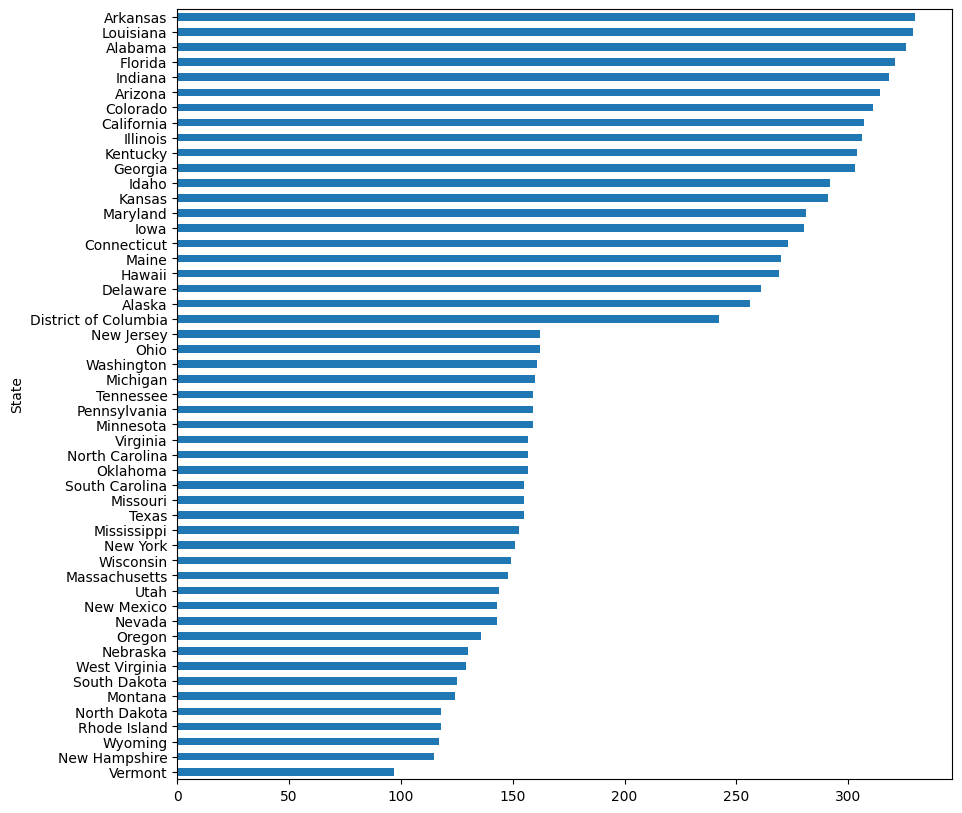

In [323]:

plt.figure(figsize=(10,10))
df["State"].value_counts().sort_values().plot(kind= "barh")

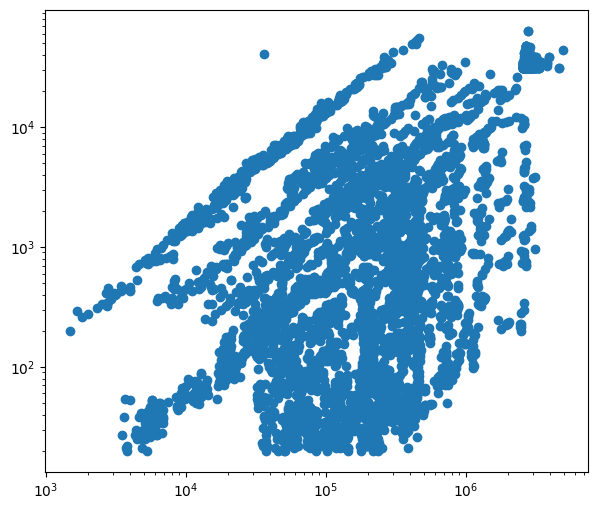

In [324]:
plot_df = df.copy()
plot_df["Population_num"] = pd.to_numeric(df["Population"], errors="coerce")
plot_df = plot_df[(plot_df["Population_num"] > 0) & (plot_df["Target"] > 0)]

plt.figure(figsize=(7, 6))
plt.scatter(plot_df["Population_num"], plot_df["Target"])
plt.xscale("log")
plt.yscale("log")

In [325]:
corre = df.corr(numeric_only=True)

corre["Target"].sort_values(ascending=True)

,Target
Crude Rate Standard Error,-0.059127
State Code,-0.043469
confidence_spread_metric,-0.040144
Id,-0.015725
qc_flag_batch_3,-0.004138
legacy_index_offset,0.004844
temp_sensor_readout,0.005526
Contributing_Cause,0.005529
Manner_of_Death,0.006483
Year,0.007034


In [326]:
df_clean = df.copy()

In [327]:
before = len(df_clean)
df_clean = df_clean[df_clean["Target"].notna() & (df_clean["Target"] >= 0)]
after = len(df_clean)

print(before, after)

11879 6743


In [328]:
df_clean["Sex"] = df_clean["Sex"].fillna(df_clean["Sex Code"])

age_code_to_label = {
    "1": "< 1 year", "1-4": "1-4 years", "5-14": "5-14 years", "15-24": "15-24 years",
    "25-34": "25-34 years", "35-44": "35-44 years", "45-54": "45-54 years",
    "55-64": "55-64 years", "65-74": "65-74 years", "75-84": "75-84 years", "85+": "85+ years",
}
df_clean["Age_Group"] = df_clean["Ten-Year Age Groups"].fillna(
    df_clean["Ten-Year Age Groups Code"].map(age_code_to_label)
)

In [329]:
df_clean["Population"] = pd.to_numeric(df_clean["Population"], errors="coerce")
df_clean.loc[df_clean["Population"] < 0, "Population"] = np.nan


In [330]:
invalid_year = (df_clean["Year"] > 2026) | ((df_clean["Year"] % 1) != 0)
print("Invalid Year values found:", invalid_year.sum(), "of", len(df_clean))

df_clean.loc[invalid_year, "Year"] = np.nan
df_clean["Year"].describe()

Invalid Year values found: 2958 of 6743


,Year
count,3785.000000
mean,2012.956935
std,4.284541
min,2006.000000
25%,2009.000000
50%,2013.000000
75%,2017.000000
max,2020.000000


In [331]:
# df_clean["Cause_Group"] = (df_clean["Underlying_Cause"] // 1000).astype(str)
# df_clean["Cause_Group"].value_counts().sort_index()

In [332]:
columns_to_drop = [
    "Id",
    "Sex Code",
    "State Code",
    "Year Code",
    "Year_dt",
    "Ten-Year Age Groups",
    "Ten-Year Age Groups Code",
    "State_Age_Combo",
    "Crude Rate",
    "Crude Rate Lower 95% Confidence Interval",
    "Crude Rate Upper 95% Confidence Interval",
    "Crude Rate Standard Error",
    "% of Total Deaths",
    "temp_sensor_readout",
    "qc_flag_batch_3",
    "legacy_index_offset",
    "adjusted_pop_trend",
    "confidence_spread_metric",
    "Contributing_Cause",
    "temporal_alignment_proxy",

]

df_clean = df_clean.drop(columns=columns_to_drop)
df_clean.shape

(6743, 8)

In [333]:
df_clean.isnull().sum().sort_values(ascending=False)


,0
Year,2958
Population,1960
State,807
Age_Group,106
Sex,91
Underlying_Cause,0
Manner_of_Death,0
Target,0


Skew of Target (raw): 2.188
Skew of log1p(Target): 0.144


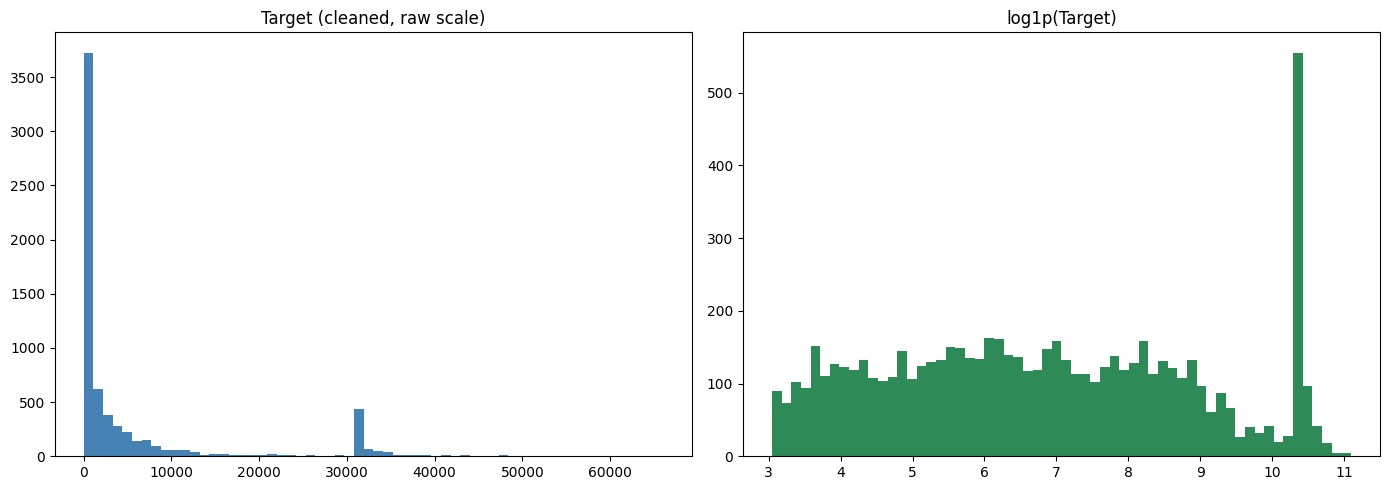

In [334]:
print("Skew of Target (raw):", df_clean["Target"].skew().round(3))
print("Skew of log1p(Target):", np.log1p(df_clean["Target"]).skew().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_clean["Target"], bins=60, color="steelblue")
axes[0].set_title("Target (cleaned, raw scale)")

axes[1].hist(np.log1p(df_clean["Target"]), bins=60, color="seagreen")
axes[1].set_title("log1p(Target)")
plt.tight_layout()
plt.show()

In [335]:
typemapping = {
    1: "Accident",
    2: "Suicide",
    3: "Murder",
    4: "Natural"
}

df_clean["Manner_of_Death"] = df_clean["Manner_of_Death"].map(typemapping)

In [336]:
df_clean

,Sex,State,Year,Population,Underlying_Cause,Manner_of_Death,Target,Age_Group
2,F,Alabama,2006.0,3.056830e+05,1171,Natural,55.000000,5-14 years
4,F,Alabama,2006.0,3.004300e+05,5361,Suicide,327.000000,25-34 years
7,F,Alabama,2006.0,2.735190e+05,7665,Suicide,2394.000000,55-64 years
8,F,NaN,2006.0,1.829410e+05,9257,Accident,3595.000000,65-74 years
9,F,Alabama,2006.0,NaN,1951,Suicide,6704.000000,75-84 years
...,...,...,...,...,...,...,...,...
11869,M,Iowa,NaN,NaN,6673,Natural,31185.990927,35-44 years
11873,F,NaN,NaN,NaN,3006,Suicide,32067.990927,45-54 years
11874,F,Indiana,NaN,NaN,5987,Natural,42606.990927,85+ years
11876,F,Delaware,NaN,NaN,7179,Accident,30873.990927,< 1 year


In [337]:
y = np.log1p(df_clean["Target"])  # modeling target: log1p of death count
X = df_clean.drop(columns=["Target"])

numeric_features = ["Year", "Population"]
categorical_features = ["Sex", "State", "Age_Group", "Manner_of_Death"]


In [338]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [339]:
for col in numeric_features:
  X_train[col + "_was_missing"] = X_train[col].isna().astype(int)
  X_test[col + "_was_missing"] = X_test[col].isna().astype(int)

  train_median = X_train[col].median()
  X_train[col] = X_train[col].fillna(train_median)
  X_test[col] = X_test[col].fillna(train_median)






In [340]:
for col in categorical_features:
    X_train[col] = X_train[col].fillna("Unknown")
    X_test[col] = X_test[col].fillna("Unknown")



In [341]:
X_train_encode = pd.get_dummies(X_train, columns=categorical_features,dtype=int)
X_test_encode = pd.get_dummies(X_test, columns=categorical_features,dtype=int)
X_test_encode = X_test_encode.reindex(columns = X_train_encode.columns, fill_value=0)


In [342]:
X_train_encode.shape


(5394, 76)

In [343]:
X_test_encode.shape


(1349, 76)

In [345]:
scaler = StandardScaler()
X_train_scaled = X_train_encode.copy()
X_test_scaled = X_test_encode.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_encode[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_encode[numeric_features])


In [348]:
linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)

pred_log = linear_reg.predict(X_test_scaled)
pred = np.clip(np.expm1(pred_log), 0, None)
actual = np.expm1(y_test)

In [350]:
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print(f"MAE: {mae:.1f}  RMSE: {rmse:.1f}  R2: {r2:.3f}")

MAE: 4899.4  RMSE: 17834.6  R2: -2.272


In [351]:
forest = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
forest.fit(X_train_scaled, y_train)

pred_log = forest.predict(X_test_scaled)
pred = np.clip(np.expm1(pred_log), 0, None)

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print(f"MAE: {mae:.1f}  RMSE: {rmse:.1f}  R2: {r2:.3f}")

MAE: 2580.9  RMSE: 7492.4  R2: 0.423


In [353]:
from sklearn.model_selection import KFold, cross_val_score


In [357]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    forest,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse_score = -cv_scores




In [360]:
cv_rmse_score

array([1.21555998, 1.21012258, 1.21569777, 1.10933385, 1.19320027])

In [359]:
cv_rmse_score.mean()

np.float64(1.188782890766701)

Gradient Boosting Regressor,
Decision Tree Regressor,
Ridge Regression,